# VAE for 2D Distribution Modeling

本notebook实现了用于2D分布建模的Variational Autoencoder (VAE)。

## 目标
- 实现基础VAE架构
- 在复杂2D分布上训练VAE
- 可视化训练过程和结果
- 对比不同β值的效果
- 与Flow-Matching结果进行比较

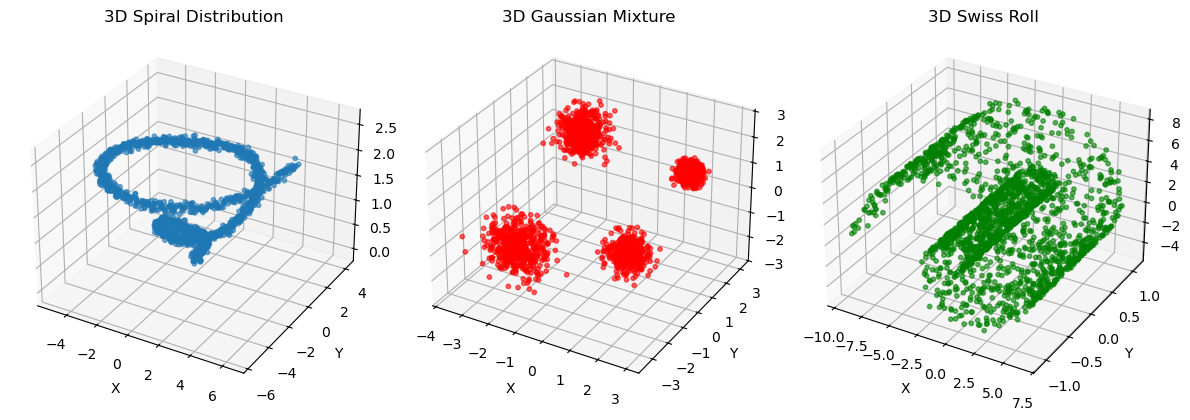

Using device: mps


In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple, Optional
import math
from tqdm import tqdm

from distributions import (
    spiral_distribution_3d, 
    moons_distribution_3d,
    gaussian_mixture_4_3d, 
    swiss_roll_3d, 
    visualize_3d_distributions
)

visualize_3d_distributions(n_samples=2000)
# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

## 1. 目标分布定义

复用Flow-Matching中的2D分布函数

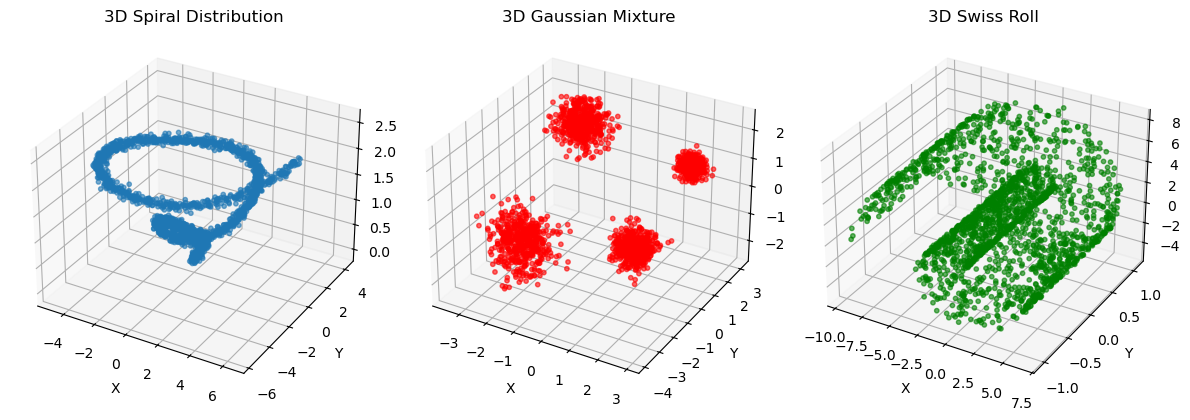

In [2]:
from distributions import spiral_distribution_3d, gaussian_mixture_4_3d, swiss_roll_3d, visualize_3d_distributions

visualize_3d_distributions(n_samples=2000)

## 2. VAE模型实现

### VAE架构
- Encoder: x → (μ, log_σ²)
- Reparameterization: z = μ + σ * ε
- Decoder: z → x_reconstructed

In [3]:
class VAE(nn.Module):
    """Variational Autoencoder for 2D distribution modeling"""
    
    def __init__(self,
                 input_dim: int = 2,
                 latent_dim: int = 2,
                 hidden_dims: list = [64, 128],
                 beta: float = 1.0):
        """
        Args:
            input_dim: Dimension of input data (2 for 2D distributions)
            latent_dim: Dimension of latent space
            hidden_dims: List of hidden layer dimensions
            beta: Beta parameter for β-VAE (1.0 = standard VAE)
        """
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.beta = beta
        
        # Build encoder
        encoder_layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            in_dim = h_dim
        
        self.encoder = nn.Sequential(*encoder_layers)
        self.fc_mu = nn.Linear(in_dim, latent_dim)
        self.fc_log_var = nn.Linear(in_dim, latent_dim)
        
        # Build decoder
        decoder_layers = []
        in_dim = latent_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            in_dim = h_dim
        
        decoder_layers.append(nn.Linear(in_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Encode input to latent space parameters"""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var
    
    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        """Reparameterization trick: z = μ + σ * ε"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent variable to reconstruction"""
        return self.decoder(z)
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Forward pass through VAE"""
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        
        return {
            'x_recon': x_recon,
            'mu': mu,
            'log_var': log_var,
            'z': z
        }
    
    def sample(self, num_samples: int, device: torch.device) -> torch.Tensor:
        """Generate samples from the learned distribution"""
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim, device=device)
            samples = self.decode(z)
            return samples
    
    def compute_loss(self, x: torch.Tensor, reduction: str = 'mean') -> Dict[str, torch.Tensor]:
        """Compute VAE loss: L = Reconstruction Loss + β * KL Divergence"""
        output = self.forward(x)
        x_recon = output['x_recon']
        mu = output['mu']
        log_var = output['log_var']
        
        # Reconstruction loss (MSE)
        recon_loss = F.mse_loss(x_recon, x, reduction=reduction)
        
        # KL divergence: KL(q(z|x) || p(z)) where p(z) = N(0,I)
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        
        if reduction == 'mean':
            kl_loss = kl_loss / x.size(0)
        
        total_loss = recon_loss + self.beta * kl_loss
        
        return {
            'total_loss': total_loss,
            'recon_loss': recon_loss,
            'kl_loss': kl_loss
        }

## 3. 训练函数

In [4]:
def train_vae(vae, data_func, n_epochs=1000, batch_size=256, lr=1e-3, n_samples_per_epoch=5000):
    """
    Train VAE on a given distribution
    
    Args:
        vae: VAE model
        data_func: Function to generate training data
        n_epochs: Number of training epochs
        batch_size: Batch size
        lr: Learning rate
        n_samples_per_epoch: Number of samples to generate per epoch
    
    Returns:
        Dictionary with training history
    """
    vae.to(device)
    optimizer = optim.Adam(vae.parameters(), lr=lr)
    
    history = {
        'total_loss': [],
        'recon_loss': [], 
        'kl_loss': []
    }
    
    for epoch in tqdm(range(n_epochs), desc="Training VAE"):
        # Generate fresh training data each epoch
        data = data_func(n_samples_per_epoch).to(device)
        
        epoch_losses = {'total_loss': 0, 'recon_loss': 0, 'kl_loss': 0}
        n_batches = 0
        
        # Mini-batch training
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            
            optimizer.zero_grad()
            loss_dict = vae.compute_loss(batch)
            loss_dict['total_loss'].backward()
            optimizer.step()
            
            # Accumulate losses
            for key in epoch_losses:
                epoch_losses[key] += loss_dict[key].item()
            n_batches += 1
        
        # Average losses for the epoch
        for key in epoch_losses:
            epoch_losses[key] /= n_batches
            history[key].append(epoch_losses[key])
        
        # Print progress
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Total Loss = {epoch_losses['total_loss']:.4f}, "
                  f"Recon = {epoch_losses['recon_loss']:.4f}, KL = {epoch_losses['kl_loss']:.4f}")
    
    return history

In [5]:
def visualize_vae_results(vae, data_func, history, n_samples=2000, is_3d=False):
    """
    Visualize VAE training results and generated samples
    Supports both 2D and 3D data visualization
    """
    vae.eval()
    
    # Generate original and VAE samples
    with torch.no_grad():
        original_data = data_func(n_samples).cpu().numpy()
        vae_samples = vae.sample(n_samples, device).cpu().numpy()
        
        # Get latent representations of original data
        original_tensor = torch.from_numpy(original_data).float().to(device)
        mu, log_var = vae.encode(original_tensor)
        latent_repr = mu.cpu().numpy()
        
        # Reconstruct original data
        reconstructed = vae.decode(mu).cpu().numpy()
    
    # Create visualization based on data dimension
    if is_3d:
        # 3D visualization
        fig = plt.figure(figsize=(20, 15))
        
        # Top row: Training curves and latent space (2D)
        ax1 = fig.add_subplot(2, 3, 1)
        ax1.plot(history['total_loss'], label='Total Loss', color='red')
        ax1.set_title('Total Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_yscale('log')
        ax1.grid(True)
        
        ax2 = fig.add_subplot(2, 3, 2)
        ax2.plot(history['recon_loss'], label='Reconstruction', color='blue')
        ax2.plot(history['kl_loss'], label='KL Divergence', color='green')
        ax2.set_title('Loss Components')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.set_yscale('log')
        ax2.legend()
        ax2.grid(True)
        
        ax3 = fig.add_subplot(2, 3, 3)
        ax3.scatter(latent_repr[:, 0], latent_repr[:, 1], alpha=0.6, s=10, c='purple')
        ax3.set_title('2D Latent Space Representation')
        ax3.set_xlabel('Latent Dim 1')
        ax3.set_ylabel('Latent Dim 2')
        ax3.grid(True)
        ax3.set_aspect('equal', adjustable='box')
        
        # Bottom row: 3D data visualizations
        ax4 = fig.add_subplot(2, 3, 4, projection='3d')
        ax4.scatter(original_data[:, 0], original_data[:, 1], original_data[:, 2], 
                   alpha=0.6, s=10, c='blue')
        ax4.set_title('Original 3D Distribution')
        ax4.set_xlabel('X')
        ax4.set_ylabel('Y')
        ax4.set_zlabel('Z')
        
        ax5 = fig.add_subplot(2, 3, 5, projection='3d')
        ax5.scatter(reconstructed[:, 0], reconstructed[:, 1], reconstructed[:, 2], 
                   alpha=0.6, s=10, c='orange')
        ax5.set_title('Reconstructed 3D Data')
        ax5.set_xlabel('X')
        ax5.set_ylabel('Y')
        ax5.set_zlabel('Z')
        
        ax6 = fig.add_subplot(2, 3, 6, projection='3d')
        ax6.scatter(vae_samples[:, 0], vae_samples[:, 1], vae_samples[:, 2], 
                   alpha=0.6, s=10, c='red')
        ax6.set_title('VAE Generated 3D Samples')
        ax6.set_xlabel('X')
        ax6.set_ylabel('Y')
        ax6.set_zlabel('Z')
        
    else:
        # Original 2D visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Training loss curves
        axes[0, 0].plot(history['total_loss'], label='Total Loss', color='red')
        axes[0, 0].set_title('Total Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_yscale('log')
        axes[0, 0].grid(True)
        
        axes[0, 1].plot(history['recon_loss'], label='Reconstruction', color='blue')
        axes[0, 1].plot(history['kl_loss'], label='KL Divergence', color='green')
        axes[0, 1].set_title('Loss Components')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].set_yscale('log')
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # Latent space visualization
        axes[0, 2].scatter(latent_repr[:, 0], latent_repr[:, 1], alpha=0.6, s=10, c='purple')
        axes[0, 2].set_title('Latent Space Representation')
        axes[0, 2].set_xlabel('Latent Dim 1')
        axes[0, 2].set_ylabel('Latent Dim 2')
        axes[0, 2].grid(True)
        axes[0, 2].set_aspect('equal', adjustable='box')
        
        # Original data
        axes[1, 0].scatter(original_data[:, 0], original_data[:, 1], alpha=0.6, s=10, c='blue')
        axes[1, 0].set_title('Original Distribution')
        axes[1, 0].grid(True)
        axes[1, 0].set_aspect('equal', adjustable='box')
        
        # Reconstructed data
        axes[1, 1].scatter(reconstructed[:, 0], reconstructed[:, 1], alpha=0.6, s=10, c='orange')
        axes[1, 1].set_title('Reconstructed Data')
        axes[1, 1].grid(True)
        axes[1, 1].set_aspect('equal', adjustable='box')
        
        # Generated samples
        axes[1, 2].scatter(vae_samples[:, 0], vae_samples[:, 1], alpha=0.6, s=10, c='red')
        axes[1, 2].set_title('VAE Generated Samples')
        axes[1, 2].grid(True)
        axes[1, 2].set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    recon_error = np.mean((original_data - reconstructed) ** 2)
    print(f"Final Reconstruction Error (MSE): {recon_error:.6f}")
    print(f"Latent space mean: {latent_repr.mean(axis=0)}")
    print(f"Latent space std: {latent_repr.std(axis=0)}")
    print(f"Data dimensionality: {original_data.shape[1]}D → {latent_repr.shape[1]}D latent → {vae_samples.shape[1]}D generated")

## 5. 实验：在Spiral分布上训练VAE

让我们先在spiral分布上测试VAE

Training VAE:   1%|          | 3/500 [00:00<02:11,  3.77it/s]

Epoch 0: Total Loss = 5.9487, Recon = 5.8123, KL = 0.1365


Training VAE:  21%|██        | 103/500 [00:08<00:30, 12.85it/s]

Epoch 100: Total Loss = 4.0752, Recon = 3.4880, KL = 0.5872


Training VAE:  41%|████      | 203/500 [00:16<00:23, 12.74it/s]

...

Training VAE:  61%|██████    | 303/500 [00:24<00:15, 12.40it/s]

Epoch 300: Total Loss = 3.1523, Recon = 1.8932, KL = 1.2591


Training VAE:  81%|████████  | 403/500 [00:32<00:07, 12.71it/s]

Epoch 400: Total Loss = 3.1119, Recon = 1.7991, KL = 1.3128


Training VAE: 100%|██████████| 500/500 [00:40<00:00, 12.43it/s]


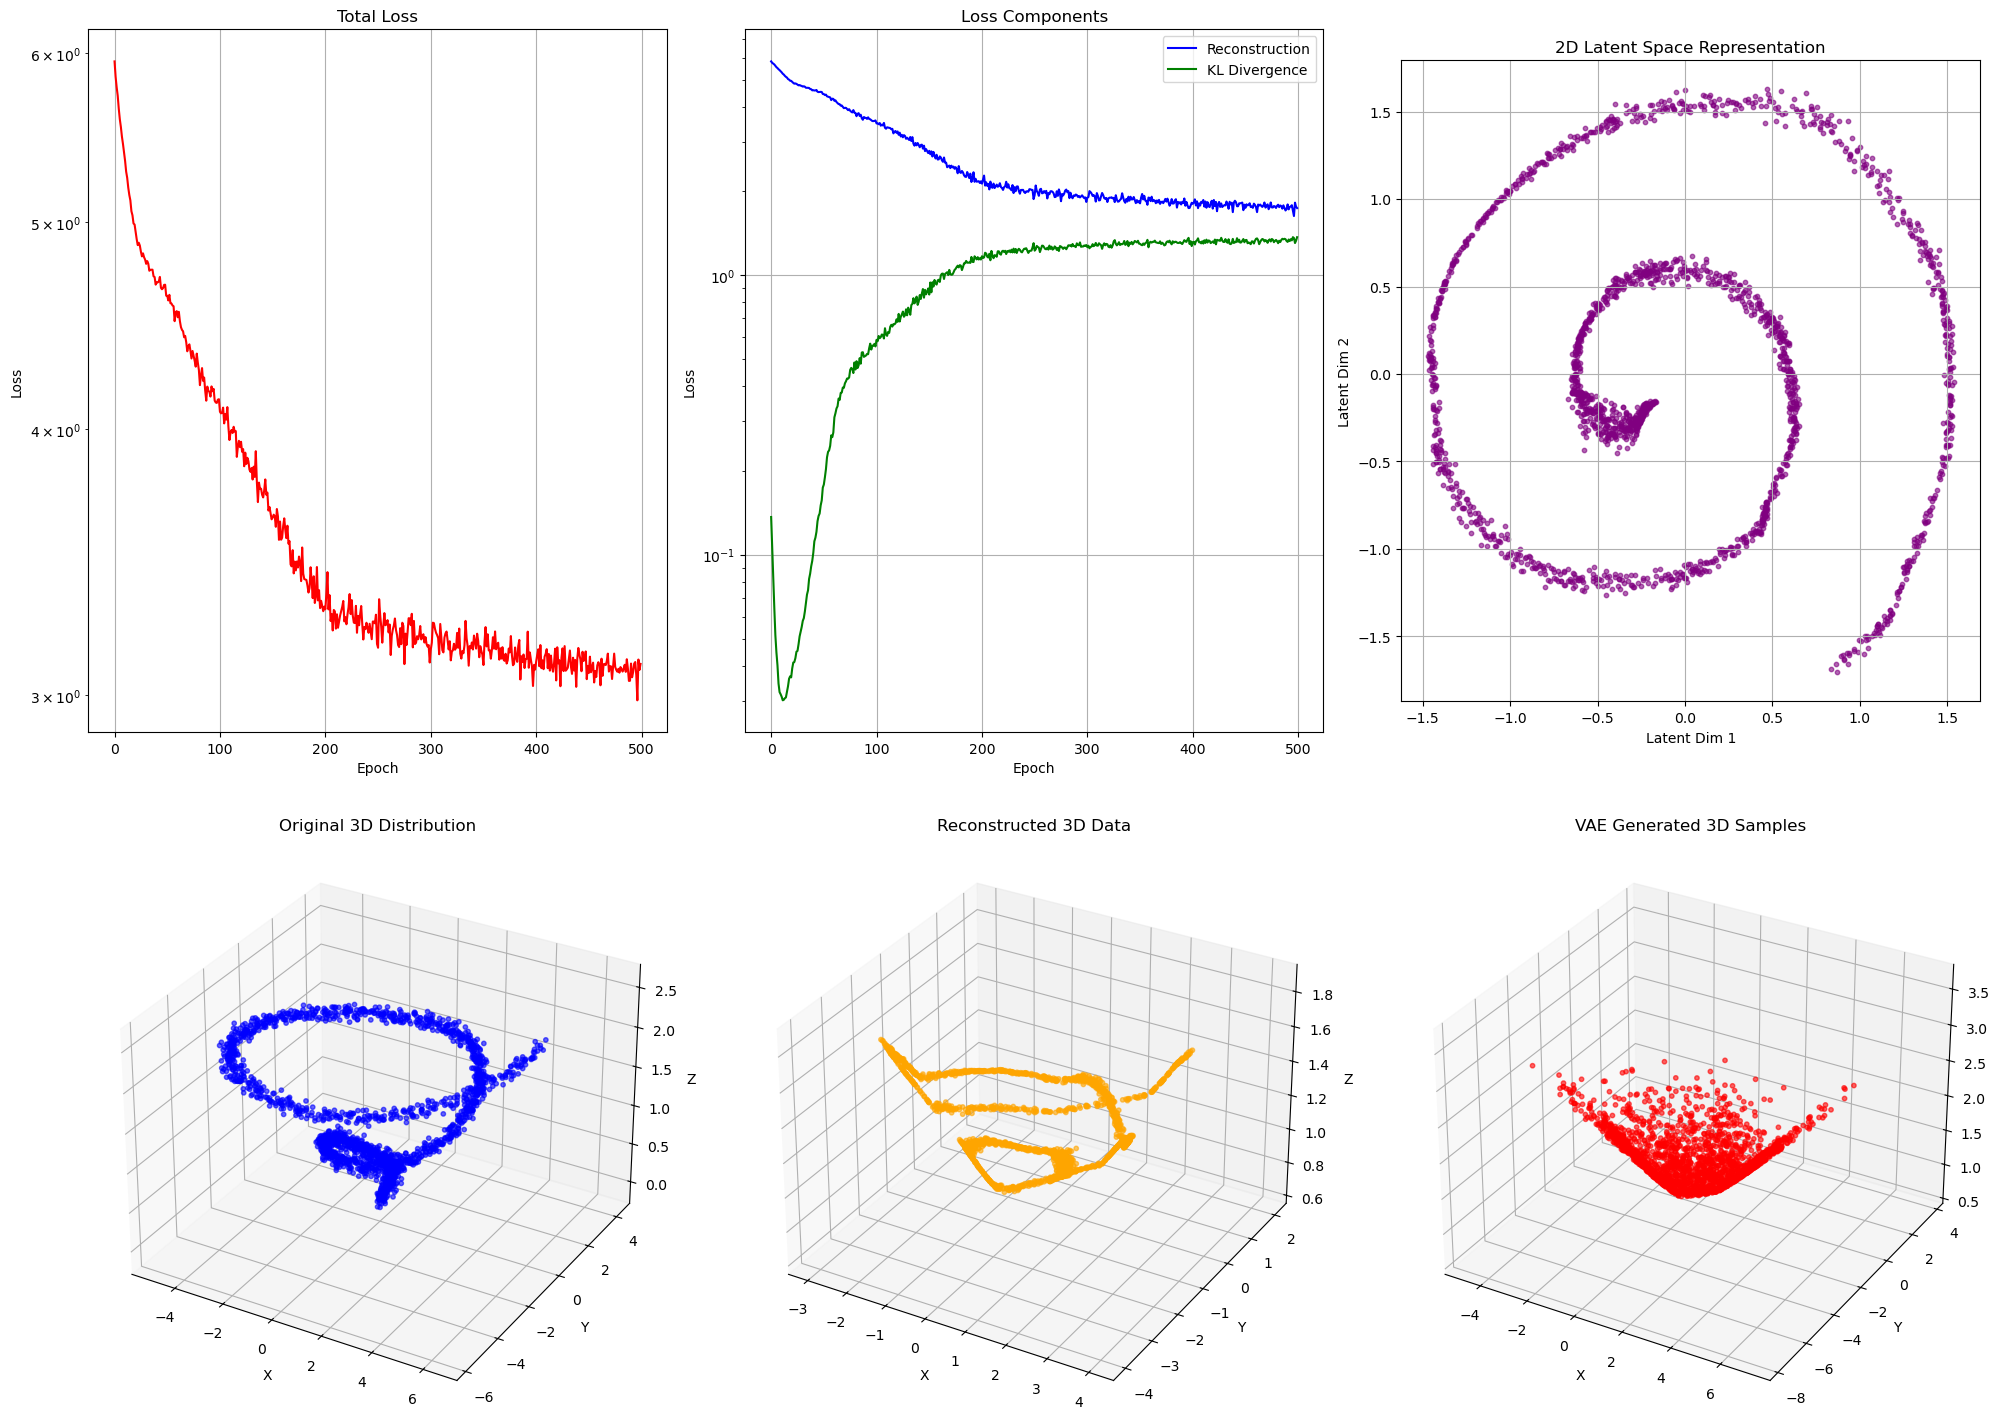

Final Reconstruction Error (MSE): 0.739587
Latent space mean: [-0.06384887  0.02251271]
Latent space std: [0.81296843 0.7955747 ]
Data dimensionality: 3D → 2D latent → 3D generated


In [ ]:
vae_eg = VAE(input_dim=3, latent_dim=2, hidden_dims=[8, 16], beta=1.0)
vae_eg.to(device)
vae_his = train_vae(
    vae_eg, 
    spiral_distribution_3d, 
    n_epochs=500, 
    batch_size=128, 
    lr=5e-4, 
    n_samples_per_epoch=2000
)
visualize_vae_results(vae_eg, moons_distribution_3d, vae_his, n_samples=2000, is_3d=True)

## 6. β-VAE对比实验

对比不同β值对VAE性能的影响


Training 3D VAE with β = 0.1


Training VAE:   0%|          | 1/500 [00:00<03:33,  2.33it/s]

Epoch 0: Total Loss = 5.1092, Recon = 5.0695, KL = 0.3962


Training VAE:  20%|██        | 102/500 [00:21<01:20,  4.97it/s]

Epoch 100: Total Loss = 0.7309, Recon = 0.3042, KL = 4.2670


...

Training VAE:  60%|██████    | 301/500 [01:01<00:40,  4.96it/s]

Epoch 300: Total Loss = 4.1511, Recon = 2.9983, KL = 0.5764


Training VAE:  80%|████████  | 401/500 [01:22<00:21,  4.71it/s]

Epoch 400: Total Loss = 4.1082, Recon = 2.9088, KL = 0.5997


Training VAE: 100%|██████████| 500/500 [01:42<00:00,  4.86it/s]


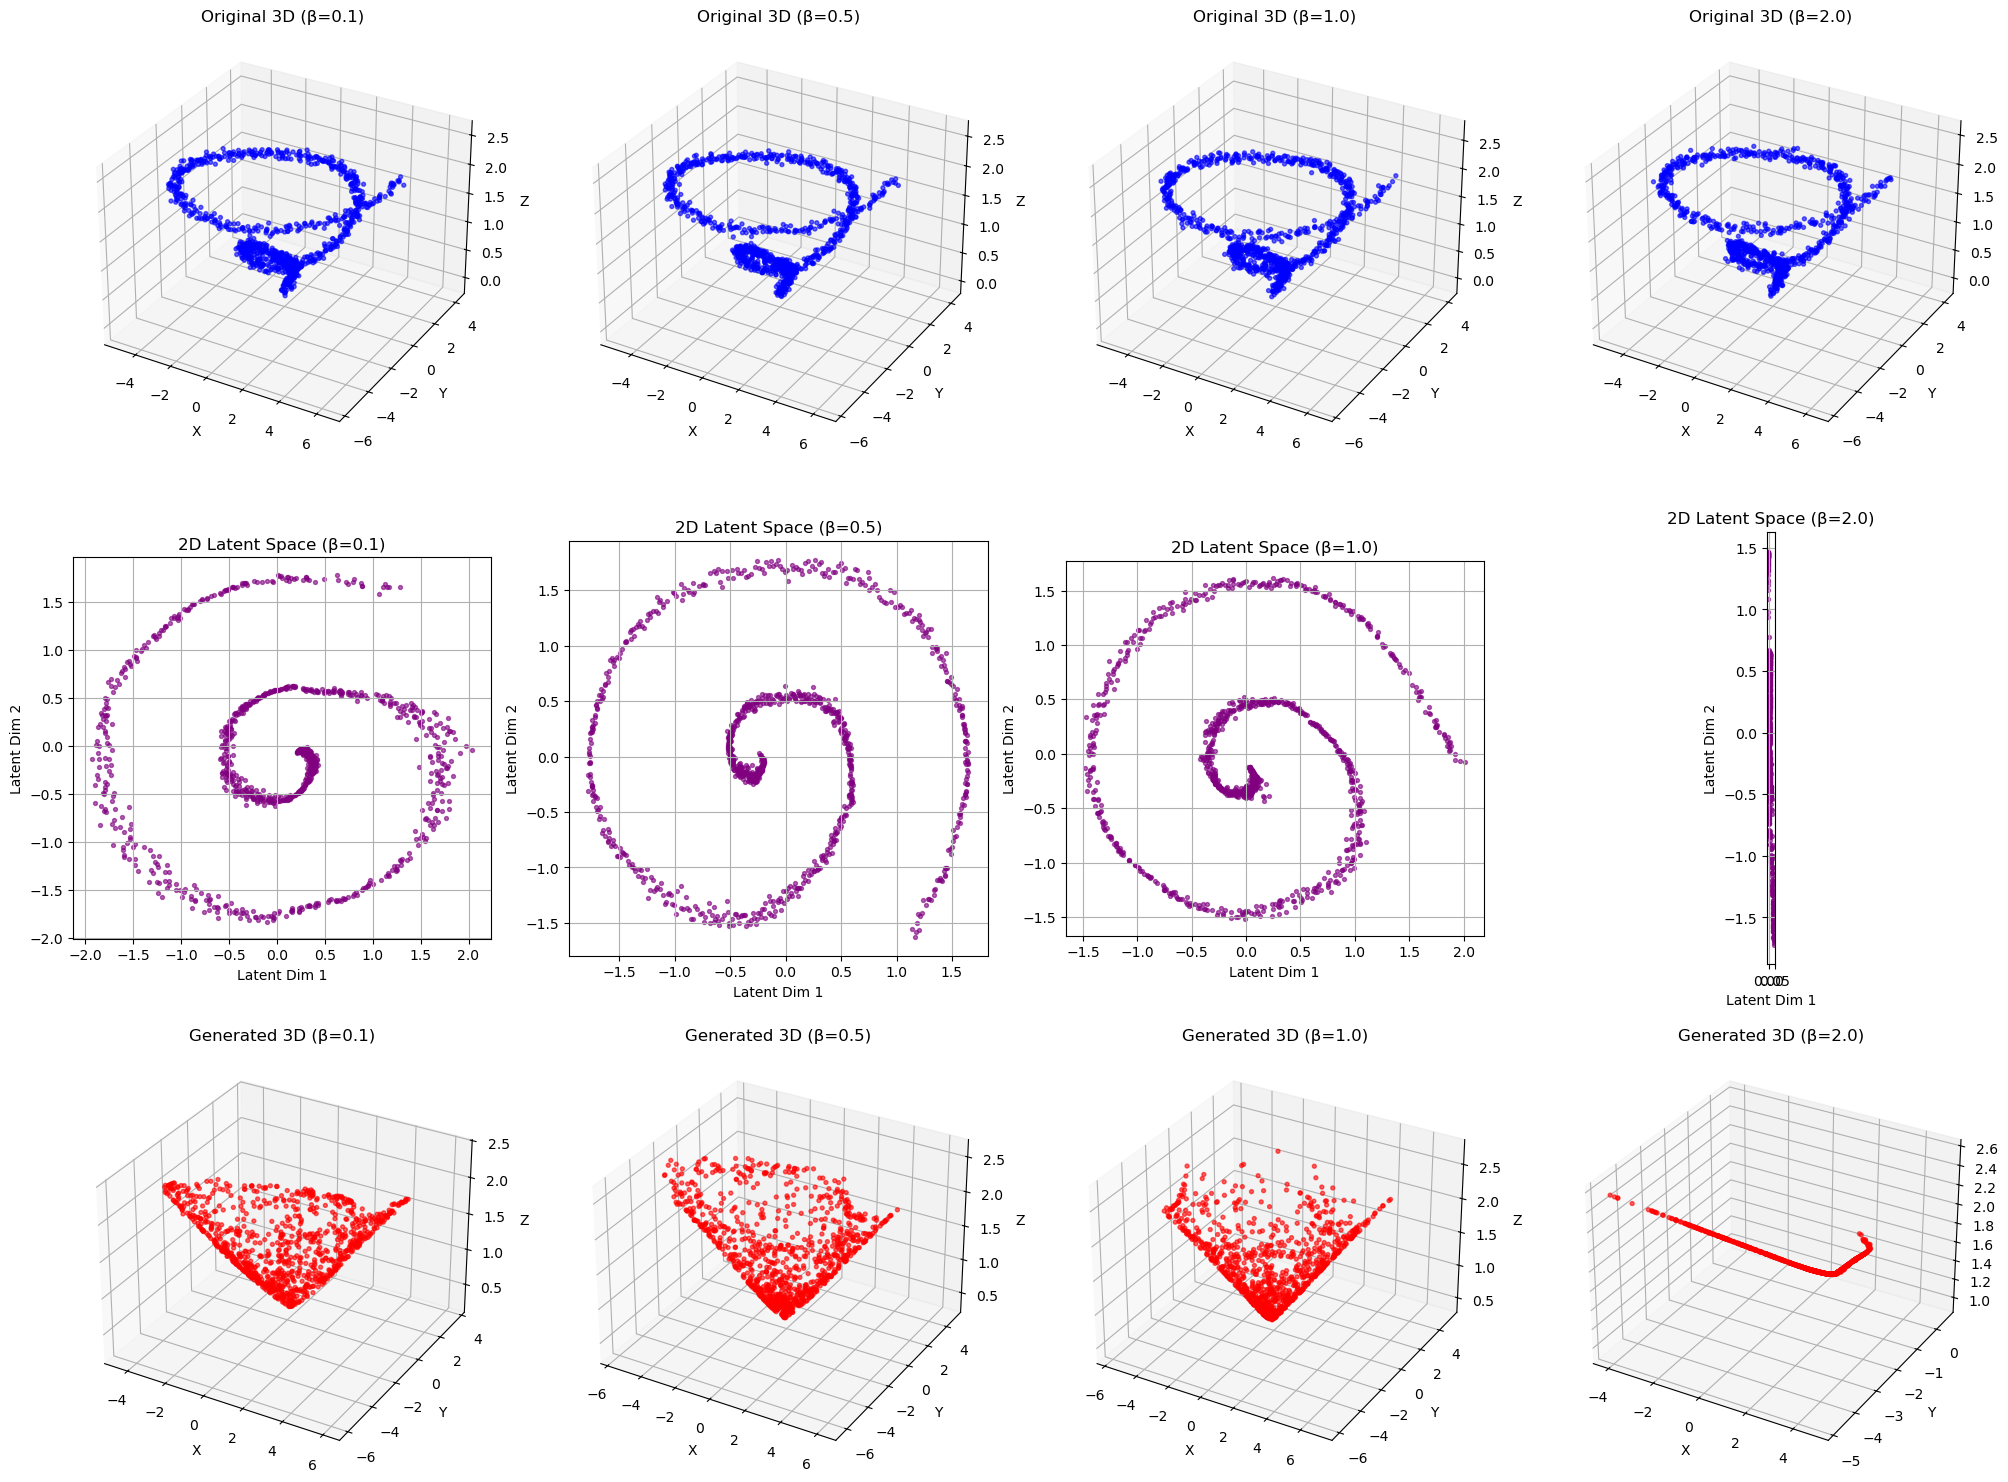

=== β-VAE Comparison Results ===
β=0.1: Final Recon Loss = 0.2839, KL Loss = 3.6211
β=0.5: Final Recon Loss = 0.7215, KL Loss = 2.1860
β=1.0: Final Recon Loss = 1.1134, KL Loss = 1.6149
β=2.0: Final Recon Loss = 2.9842, KL Loss = 0.5629


{0.1: {'vae': VAE(
    (encoder): Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=64, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
    )
    (fc_mu): Linear(in_features=128, out_features=2, bias=True)
    (fc_log_var): Linear(in_features=128, out_features=2, bias=True)
    (decoder): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=64, out_features=3, bias=True)
    )
  ),
  'history': {'total_loss': [5.109152226522565,
    3.8872381418943407,
    2.7749623984098433,
    2.4918309330940245,
    1.4272967711091042,
    1.2541251063346863,
    1.2642373509705067,
    1.1739660859107972,
    1.061509157

In [ ]:
def compare_beta_values_3d(data_func, beta_values=[0.1, 0.5, 1.0, 2.0], n_epochs=400):
    """
    Compare VAE performance with different beta values on 3D data
    Creates 3D→2D information bottleneck to test representation learning
    """
    results = {}
    
    for beta in beta_values:
        print(f"\nTraining 3D VAE with β = {beta}")
        vae = VAE(input_dim=3, latent_dim=2, hidden_dims=[64, 128], beta=beta)
        history = train_vae(vae, data_func, n_epochs=n_epochs, batch_size=128, lr=1e-3)
        results[beta] = {'vae': vae, 'history': history}
    
    # Create comprehensive 3D visualization
    fig = plt.figure(figsize=(20, 15))
    n_betas = len(beta_values)
    
    for i, beta in enumerate(beta_values):
        vae = results[beta]['vae']
        vae.eval()
        
        with torch.no_grad():
            original_data = data_func(1000).cpu().numpy()
            vae_samples = vae.sample(1000, device).cpu().numpy()
            
            # Get latent representations
            original_tensor = torch.from_numpy(original_data).float().to(device)
            mu, _ = vae.encode(original_tensor)
            latent_repr = mu.cpu().numpy()
        
        # Top row: Original 3D data
        ax1 = fig.add_subplot(3, n_betas, i+1, projection='3d')
        ax1.scatter(original_data[:, 0], original_data[:, 1], original_data[:, 2], 
                   alpha=0.6, s=8, c='blue')
        ax1.set_title(f'Original 3D (β={beta})')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_zlabel('Z')
        
        # Middle row: 2D Latent space
        ax2 = fig.add_subplot(3, n_betas, i+1+n_betas)
        ax2.scatter(latent_repr[:, 0], latent_repr[:, 1], alpha=0.6, s=8, c='purple')
        ax2.set_title(f'2D Latent Space (β={beta})')
        ax2.set_xlabel('Latent Dim 1')
        ax2.set_ylabel('Latent Dim 2')
        ax2.grid(True)
        ax2.set_aspect('equal', adjustable='box')
        
        # Bottom row: Generated 3D samples
        ax3 = fig.add_subplot(3, n_betas, i+1+2*n_betas, projection='3d')
        ax3.scatter(vae_samples[:, 0], vae_samples[:, 1], vae_samples[:, 2], 
                   alpha=0.6, s=8, c='red')
        ax3.set_title(f'Generated 3D (β={beta})')
        ax3.set_xlabel('X')
        ax3.set_ylabel('Y')
        ax3.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print("=== β-VAE Comparison Results ===")
    for beta in beta_values:
        vae = results[beta]['vae']
        history = results[beta]['history']
        final_recon = history['recon_loss'][-1]
        final_kl = history['kl_loss'][-1]
        print(f"β={beta}: Final Recon Loss = {final_recon:.4f}, KL Loss = {final_kl:.4f}")
    
    return results

compare_beta_values_3d(moons_distribution_3d, beta_values=[0.1, 0.5, 1.0, 2.0], n_epochs=500)

## 7. 多分布对比实验

在不同的2D分布上测试VAE性能

Testing 3D VAE on Spiral 3D distribution


Training VAE:   0%|          | 1/500 [00:00<01:51,  4.48it/s]

Epoch 0: Total Loss = 5.2542, Recon = 5.1780, KL = 0.0762


Training VAE:  20%|██        | 101/500 [00:20<01:20,  4.98it/s]

Epoch 100: Total Loss = 2.9520, Recon = 1.6465, KL = 1.3056


...

Training VAE:  60%|██████    | 302/500 [01:01<00:39,  4.98it/s]

Epoch 300: Total Loss = 3.2181, Recon = 1.0748, KL = 2.1433


Training VAE:  80%|████████  | 401/500 [01:21<00:20,  4.86it/s]

Epoch 400: Total Loss = 3.1684, Recon = 1.0132, KL = 2.1552


Training VAE: 100%|██████████| 500/500 [01:41<00:00,  4.90it/s]


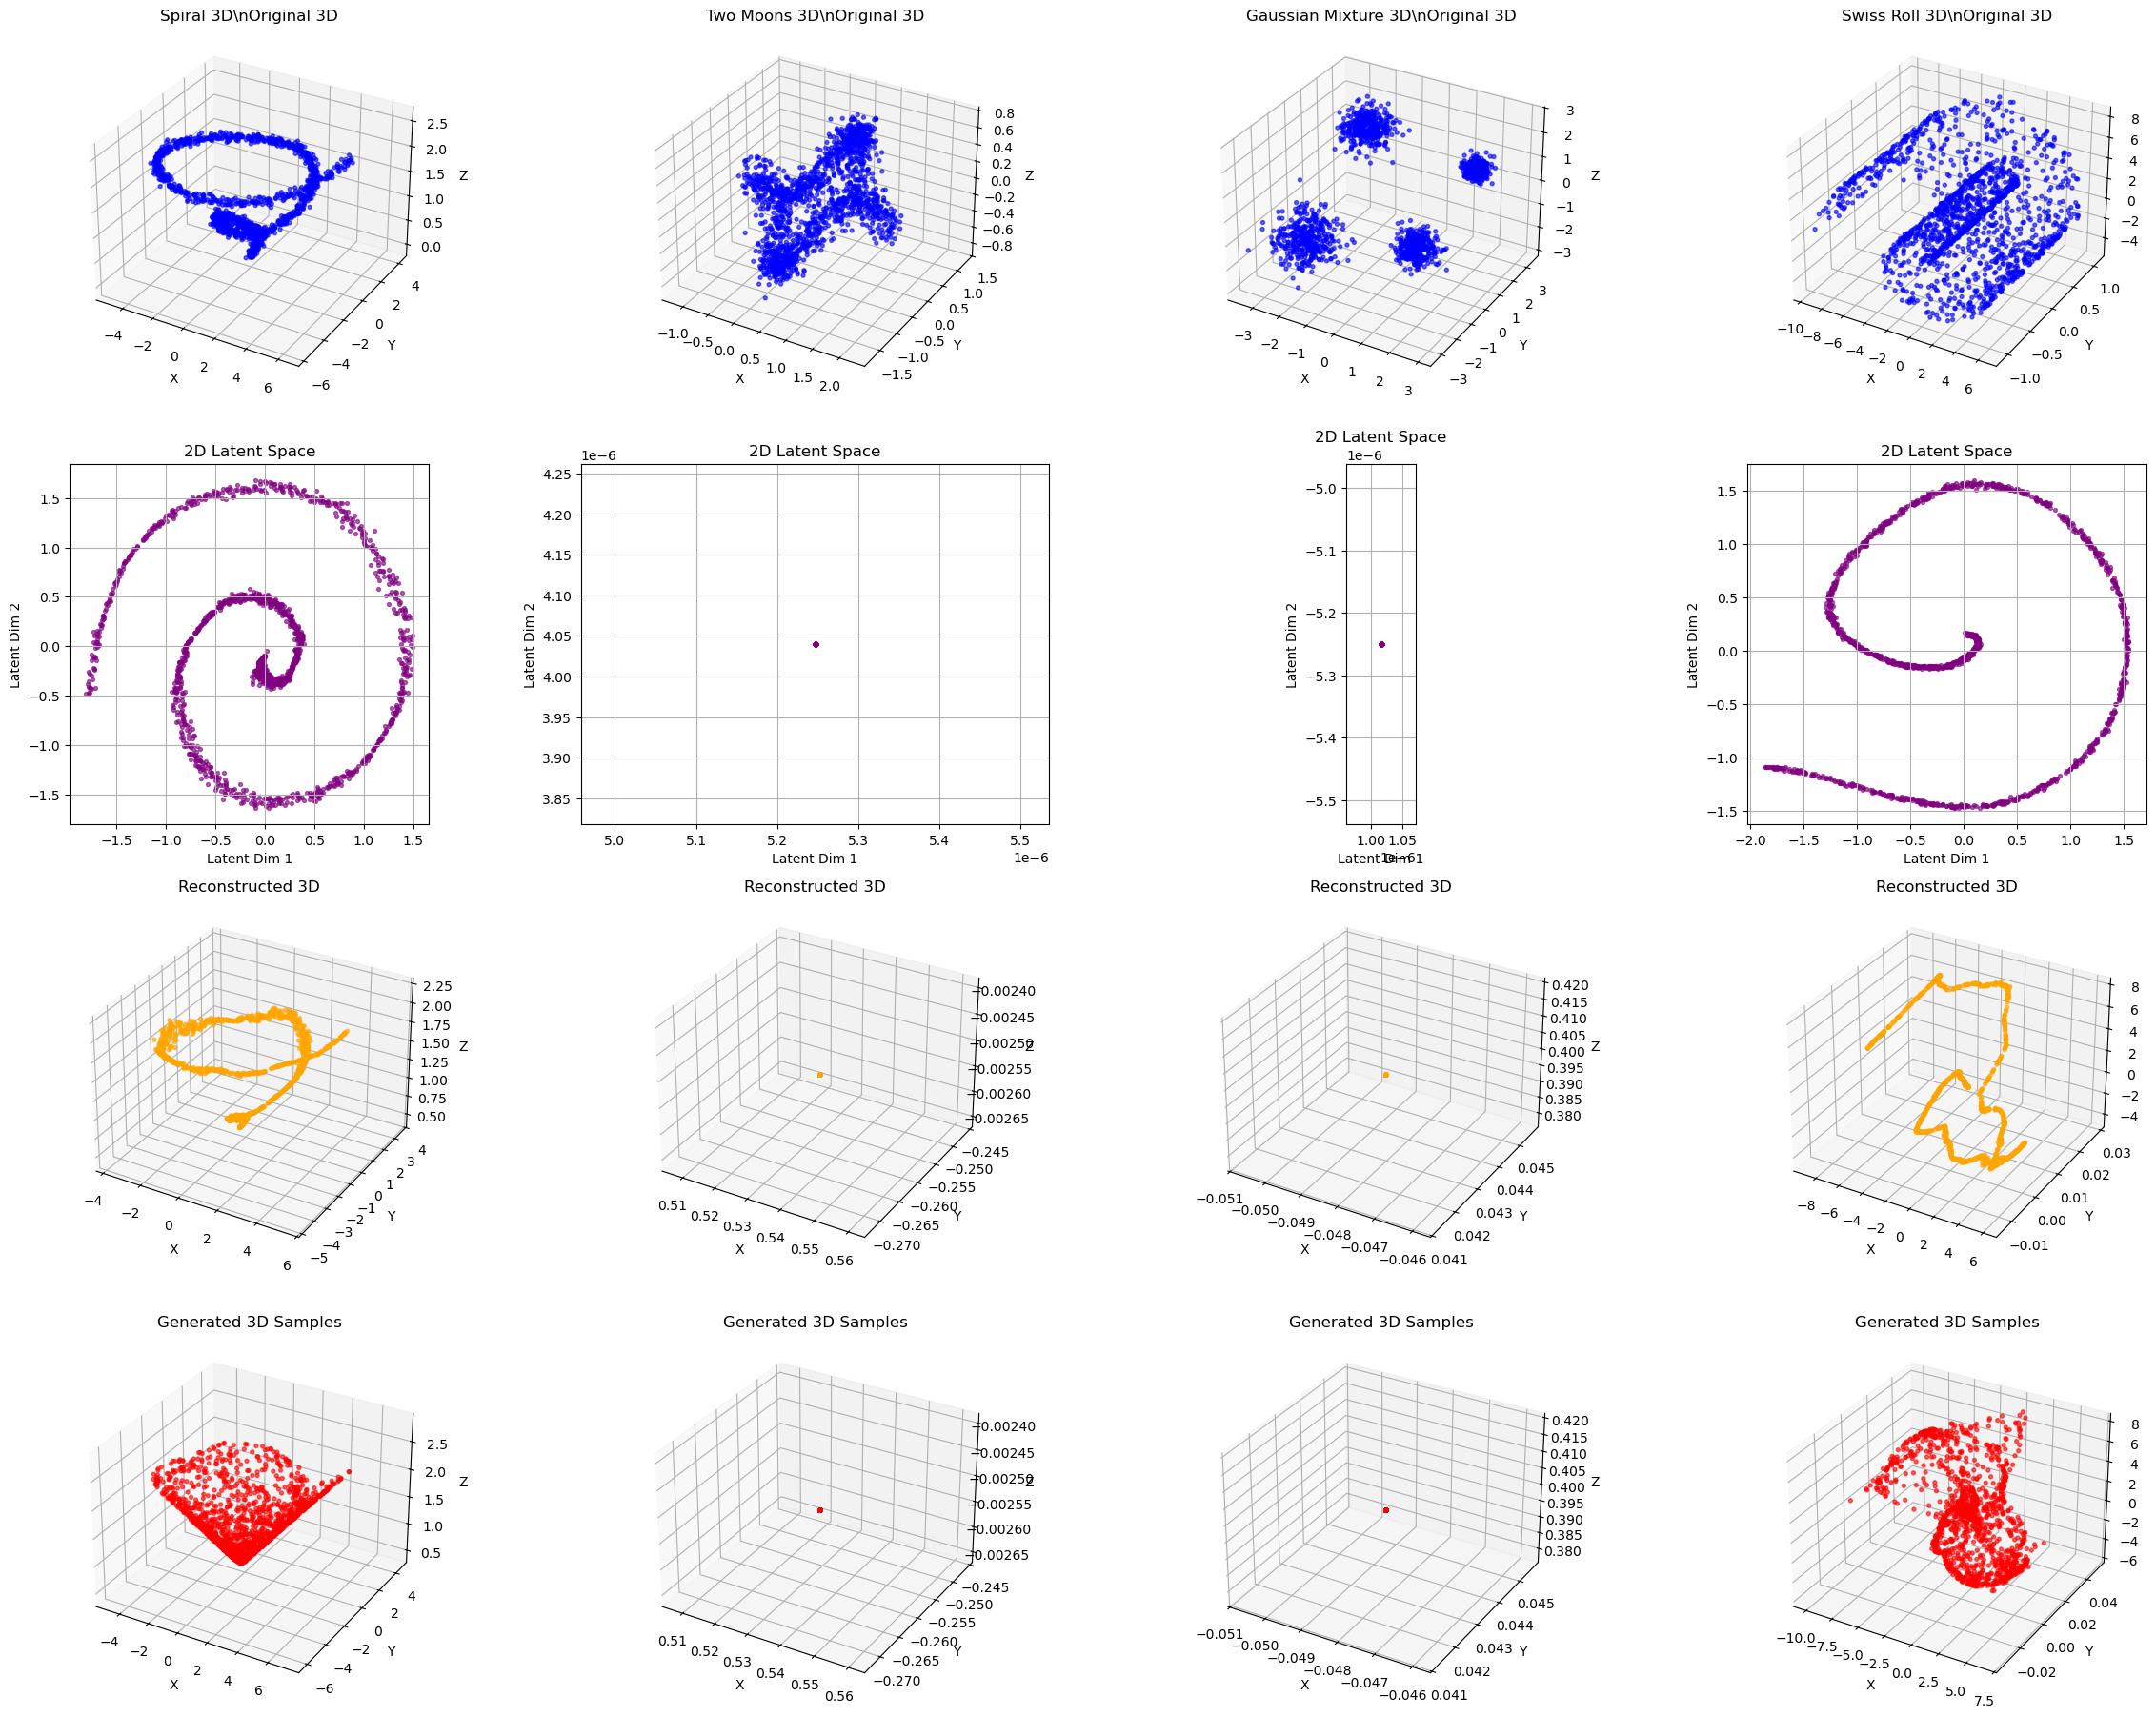

=== 3D Distribution Modeling Results ===
Spiral 3D: Recon=1.1495, KL=1.6179, Total=2.7674
Two Moons 3D: Recon=0.6044, KL=-0.0000, Total=0.6044
Gaussian Mixture 3D: Recon=3.1279, KL=-0.0000, Total=3.1279
Swiss Roll 3D: Recon=0.9953, KL=2.1318, Total=3.1271


{'Spiral 3D': {'vae': VAE(
    (encoder): Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=64, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
    )
    (fc_mu): Linear(in_features=128, out_features=2, bias=True)
    (fc_log_var): Linear(in_features=128, out_features=2, bias=True)
    (decoder): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=64, out_features=3, bias=True)
    )
  ),
  'history': {'total_loss': [5.2542025009170175,
    4.959379218518734,
    4.8554086744785305,
    4.825518487393856,
    4.77689189016819,
    4.65949534624815,
    4.416752232611179,
    4.3533027693629265,
    4.4028952

In [10]:
# 3D distributions for comparison
distributions_3d = {
    'Spiral 3D': spiral_distribution_3d,
    'Two Moons 3D': moons_distribution_3d,
    'Gaussian Mixture 3D': gaussian_mixture_4_3d,
    'Swiss Roll 3D': swiss_roll_3d
}

def test_vae_on_distributions_3d(distributions_dict, beta=1.0, n_epochs=400):
    """
    Test VAE on multiple 3D distributions with 3D→2D compression
    """
    results = {}
    
    for name, dist_func in distributions_dict.items():
        print(f"Testing 3D VAE on {name} distribution")
        vae = VAE(input_dim=3, latent_dim=2, hidden_dims=[64, 128], beta=beta)
        history = train_vae(vae, dist_func, n_epochs=n_epochs, batch_size=128, lr=1e-3)
        results[name] = {'vae': vae, 'history': history, 'dist_func': dist_func}
    
    # Create comprehensive visualization
    n_dists = len(distributions_dict)
    fig = plt.figure(figsize=(6*n_dists, 18))
    
    for i, (name, result) in enumerate(results.items()):
        vae = result['vae']
        dist_func = result['dist_func']
        history = result['history']
        vae.eval()
        
        with torch.no_grad():
            original_data = dist_func(1500).cpu().numpy()
            vae_samples = vae.sample(1500, device).cpu().numpy()
            
            # Get latent representations and reconstructions
            original_tensor = torch.from_numpy(original_data).float().to(device)
            mu, _ = vae.encode(original_tensor)
            latent_repr = mu.cpu().numpy()
            reconstructed = vae.decode(mu).cpu().numpy()
        
        # Row 1: Original 3D data
        ax1 = fig.add_subplot(4, n_dists, i+1, projection='3d')
        ax1.scatter(original_data[:, 0], original_data[:, 1], original_data[:, 2], 
                   alpha=0.6, s=8, c='blue')
        ax1.set_title(f'{name}\\nOriginal 3D')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_zlabel('Z')
        
        # Row 2: 2D Latent space representation
        ax2 = fig.add_subplot(4, n_dists, i+1+n_dists)
        ax2.scatter(latent_repr[:, 0], latent_repr[:, 1], alpha=0.6, s=8, c='purple')
        ax2.set_title('2D Latent Space')
        ax2.set_xlabel('Latent Dim 1')
        ax2.set_ylabel('Latent Dim 2')
        ax2.grid(True)
        ax2.set_aspect('equal', adjustable='box')
        
        # Row 3: Reconstructed 3D data
        ax3 = fig.add_subplot(4, n_dists, i+1+2*n_dists, projection='3d')
        ax3.scatter(reconstructed[:, 0], reconstructed[:, 1], reconstructed[:, 2], 
                   alpha=0.6, s=8, c='orange')
        ax3.set_title('Reconstructed 3D')
        ax3.set_xlabel('X')
        ax3.set_ylabel('Y')
        ax3.set_zlabel('Z')
        
        # Row 4: Generated 3D samples
        ax4 = fig.add_subplot(4, n_dists, i+1+3*n_dists, projection='3d')
        ax4.scatter(vae_samples[:, 0], vae_samples[:, 1], vae_samples[:, 2], 
                   alpha=0.6, s=8, c='red')
        ax4.set_title('Generated 3D Samples')
        ax4.set_xlabel('X')
        ax4.set_ylabel('Y')
        ax4.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()
    
    # Print performance summary
    print("=== 3D Distribution Modeling Results ===")
    for name, result in results.items():
        history = result['history']
        final_recon = history['recon_loss'][-1]
        final_kl = history['kl_loss'][-1]
        final_total = history['total_loss'][-1]
        print(f"{name}: Recon={final_recon:.4f}, KL={final_kl:.4f}, Total={final_total:.4f}")
    
    return results

test_vae_on_distributions_3d(distributions_3d, beta=1.0, n_epochs=500)

## 8. 潜在空间插值实验

验证VAE学到的潜在空间的连续性

In [9]:
def latent_interpolation_experiment_3d(vae, n_steps=10):
    """
    Perform latent space interpolation to test continuity for 3D VAE
    Shows how 2D latent space interpolation affects 3D output
    """
    vae.eval()
    
    with torch.no_grad():
        # Sample two random points in 2D latent space
        z1 = torch.randn(1, vae.latent_dim, device=device)
        z2 = torch.randn(1, vae.latent_dim, device=device)
        
        # Create interpolation in latent space
        alphas = torch.linspace(0, 1, n_steps).unsqueeze(1).to(device)
        interpolated_z = alphas * z2 + (1 - alphas) * z1
        
        # Decode interpolated latent points to 3D
        interpolated_samples = vae.decode(interpolated_z).cpu().numpy()
    
    # Enhanced visualization for 3D interpolation
    fig = plt.figure(figsize=(18, 6))
    
    # Left: 3D interpolation path
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.plot(interpolated_samples[:, 0], interpolated_samples[:, 1], interpolated_samples[:, 2], 
             'o-', markersize=8, linewidth=3, alpha=0.8)
    ax1.scatter(interpolated_samples[0, 0], interpolated_samples[0, 1], interpolated_samples[0, 2], 
                c='green', s=150, label='Start', marker='s')
    ax1.scatter(interpolated_samples[-1, 0], interpolated_samples[-1, 1], interpolated_samples[-1, 2], 
                c='red', s=150, label='End', marker='s')
    ax1.set_title('3D Interpolation Path\\n(Decoded from 2D Latent)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    # Middle: 2D latent space path
    ax2 = fig.add_subplot(1, 3, 2)
    z_interp = interpolated_z.cpu().numpy()
    ax2.plot(z_interp[:, 0], z_interp[:, 1], 'o-', markersize=8, linewidth=3, alpha=0.8)
    ax2.scatter(z_interp[0, 0], z_interp[0, 1], c='green', s=150, label='Start', marker='s')
    ax2.scatter(z_interp[-1, 0], z_interp[-1, 1], c='red', s=150, label='End', marker='s')
    ax2.set_title('2D Latent Space Path')
    ax2.set_xlabel('Latent Dim 1')
    ax2.set_ylabel('Latent Dim 2')
    ax2.legend()
    ax2.grid(True)
    ax2.set_aspect('equal', adjustable='box')
    
    # Right: Step-by-step 3D projections
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    # Use color gradient to show progression
    colors = plt.cm.viridis(np.linspace(0, 1, n_steps))
    for i in range(n_steps):
        ax3.scatter(interpolated_samples[i, 0], interpolated_samples[i, 1], interpolated_samples[i, 2], 
                   c=[colors[i]], s=100, alpha=0.8)
    ax3.set_title('Interpolation Steps\\n(Color: Blue→Yellow)')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis: projection distances
    print("=== Latent Space Interpolation Analysis ===")
    print(f"Latent space distance: {torch.norm(z2 - z1).item():.4f}")

    # Calculate 3D distances between consecutive steps
    distances_3d = []
    for i in range(1, n_steps):
        dist = np.linalg.norm(interpolated_samples[i] - interpolated_samples[i-1])
        distances_3d.append(dist)

    print(f"Average 3D step distance: {np.mean(distances_3d):.4f} ± {np.std(distances_3d):.4f}")
    print(f"3D path smoothness (std/mean): {np.std(distances_3d)/np.mean(distances_3d):.4f}")

    # Show coordinate progression
    print("\nCoordinate progression:")
    for i in range(0, n_steps, max(1, n_steps//5)):
        print(f"Step {i}: Latent=({z_interp[i, 0]:.2f}, {z_interp[i, 1]:.2f}) → "
              f"3D=({interpolated_samples[i, 0]:.2f}, {interpolated_samples[i, 1]:.2f}, {interpolated_samples[i, 2]:.2f})")

## 9. 使用示例和实验

现在所有实验函数都支持3D输入，创造真正的信息瓶颈！

```python
# β-VAE对比实验 (3D→2D)
results_beta = compare_beta_values_3d(spiral_distribution_3d, 
                                     beta_values=[0.1, 0.5, 1.0, 2.0], 
                                     n_epochs=300)

# 多分布对比实验 (3D→2D)
results_multi = test_vae_on_distributions_3d(distributions_3d, 
                                            beta=1.0, 
                                            n_epochs=400)

# 潜在空间插值实验 (2D latent → 3D output)
latent_interpolation_experiment_3d(vae_3d, n_steps=15)
```

## 10. 总结和insights

通过3D→2D的VAE设计，我们实现了：

### **信息瓶颈的价值**
- **真正的压缩**: 从3维到2维，强制学习本质特征
- **表示学习**: 不能简单记忆坐标，必须理解结构
- **维度约简**: 测试VAE的核心能力

### **实验设计的优势**
1. **β-VAE对比**: 观察不同正则化强度在信息瓶颈下的表现
2. **多分布测试**: 不同3D结构对VAE压缩能力的挑战
3. **插值分析**: 2D潜在空间如何映射到连续的3D变化

### **与Flow-Matching的对比**
- **训练效率**: VAE单次前向传播 vs Flow-Matching需要ODE求解
- **表示能力**: VAE明确的2D潜在空间 vs Flow-Matching隐式路径
- **生成质量**: 需要实际对比在相同3D分布上的表现
- **可解释性**: VAE潜在维度具有几何意义

### **关键发现**
- 信息瓶颈迫使VAE学习有意义的表示
- 2D潜在空间能否充分表示复杂3D结构？
- β参数在真正压缩场景下的作用更加明显